# HW3 – Tone mapping HDR en CUDA
Introduction to Parallel Programming (Udacity CS344).

Se implementan en GPU: **reducción paralela** (mínimo y máximo), **histograma** y **scan exclusivo** (CDF), que se usan para convertir una imagen HDR en una imagen visible.

**Antes de empezar:** Entorno de ejecución → Cambiar tipo de entorno → **GPU (T4)**. Luego Entorno de ejecución → Ejecutar todas.

In [1]:
!nvidia-smi

Tue Sep 29 16:41:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Instalar OpenCV (lo necesita el código del curso para leer y guardar imágenes)
Tarda uno o dos minutos.

In [2]:
!apt-get -qq update > /dev/null && apt-get -qq install -y libopencv-dev pkg-config > /dev/null && echo 'OpenCV instalado:' && pkg-config --modversion opencv4

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
OpenCV instalado:
4.6.0


## 2. Clonar el repositorio y adaptar el código a OpenCV 4
El código original usa constantes de OpenCV 2 que ya no existen; se reemplazan por sus equivalentes actuales.

In [3]:
%cd /content
!rm -rf udacity-cs344-colab
!git clone -q https://github.com/depctg/udacity-cs344-colab.git
%cd /content/udacity-cs344-colab/src/HW3
!sed -i -E 's/CV_LOAD_IMAGE_/cv::IMREAD_/g; s/\bCV_([A-Z]+)2([A-Z]+)\b/cv::COLOR_\12\2/g; s/cudaThreadSynchronize/cudaDeviceSynchronize/g' *.cpp *.cu *.h
!ls

/content
/content/udacity-cs344-colab/src/HW3
CMakeLists.txt	   Makefile		    reference_calc.cpp
compare.cpp	   memorial.exr		    reference_calc.h
compare.h	   memorial_large.exr	    student_func.cu
HW3.cu		   memorial_png.gold	    timer.h
loadSaveImage.cpp  memorial_png_large.gold  utils.h
loadSaveImage.h    memorial_raw_large.png
main.cpp	   memorial_raw.png


## 3. Código del estudiante

In [4]:
%%writefile /content/udacity-cs344-colab/src/HW3/student_func.cu
/*
 * HW3 - Tone mapping HDR en CUDA
 * Curso: Introduction to Parallel Programming (Udacity CS344)
 *
 * Pasos paralelos que se implementan:
 *  1) Reducción paralela (min y max) de la luminancia logarítmica,
 *     en varias pasadas con memoria compartida.
 *  2) Histograma de la luminancia en numBins bins, con histogramas
 *     privados por bloque en memoria compartida + atomicAdd.
 *  3) Scan exclusivo (suma prefija) del histograma para obtener la CDF,
 *     con el algoritmo de Hillis-Steele en un solo bloque.
 * La CDF la usa luego el código del curso para mapear el HDR a una imagen normal.
 */

#include "utils.h"
#include <cfloat>

// ---------------------------------------------------------------------------
// 1) Reducción min/max: cada bloque reduce 2*blockDim elementos
// ---------------------------------------------------------------------------
__global__
void k_reduceMinMax(const float* const inMin, const float* const inMax,
                    float* const outMin, float* const outMax, size_t n)
{
  extern __shared__ float sdata[];
  float* sMin = sdata;
  float* sMax = sdata + blockDim.x;

  unsigned int tid = threadIdx.x;
  size_t i = (size_t)blockIdx.x * blockDim.x * 2 + tid;

  float mn = FLT_MAX, mx = -FLT_MAX;
  if (i < n)              { mn = fminf(mn, inMin[i]);              mx = fmaxf(mx, inMax[i]); }
  if (i + blockDim.x < n) { mn = fminf(mn, inMin[i + blockDim.x]); mx = fmaxf(mx, inMax[i + blockDim.x]); }
  sMin[tid] = mn;
  sMax[tid] = mx;
  __syncthreads();

  for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) {
    if (tid < s) {
      sMin[tid] = fminf(sMin[tid], sMin[tid + s]);
      sMax[tid] = fmaxf(sMax[tid], sMax[tid + s]);
    }
    __syncthreads();
  }
  if (tid == 0) {
    outMin[blockIdx.x] = sMin[0];
    outMax[blockIdx.x] = sMax[0];
  }
}

// ---------------------------------------------------------------------------
// 2) Histograma con histograma privado por bloque en memoria compartida
//    (la fórmula del bin es la misma del código de referencia; se usan
//    operaciones con redondeo exacto para que coincida con la CPU)
// ---------------------------------------------------------------------------
__global__
void k_histogram(const float* const lum, unsigned int* const histo,
                 size_t n, float minL, float range, int numBins)
{
  extern __shared__ unsigned int sHist[];
  for (int b = threadIdx.x; b < numBins; b += blockDim.x) sHist[b] = 0;
  __syncthreads();

  size_t idx    = (size_t)blockIdx.x * blockDim.x + threadIdx.x;
  size_t stride = (size_t)blockDim.x * gridDim.x;
  for (size_t i = idx; i < n; i += stride) {
    float t = __fmul_rn(__fdiv_rn(__fsub_rn(lum[i], minL), range), (float)numBins);
    unsigned int bin = (unsigned int)t;
    if (bin > (unsigned int)(numBins - 1)) bin = numBins - 1;
    atomicAdd(&sHist[bin], 1u);
  }
  __syncthreads();

  for (int b = threadIdx.x; b < numBins; b += blockDim.x) {
    unsigned int c = sHist[b];
    if (c) atomicAdd(&histo[b], c);
  }
}

// ---------------------------------------------------------------------------
// 3) Scan exclusivo en un solo bloque (Hillis-Steele).
//    Cada hilo suma un tramo consecutivo, se escanean las sumas de los hilos
//    y luego cada hilo escribe su tramo. Sirve para cualquier numBins.
// ---------------------------------------------------------------------------
__global__
void k_exclusiveScan(const unsigned int* const in, unsigned int* const out, int n)
{
  extern __shared__ unsigned int sScan[];
  int tid = threadIdx.x, T = blockDim.x;
  int per   = (n + T - 1) / T;
  int start = tid * per;
  int end   = min(start + per, n);

  unsigned int local = 0;
  for (int i = start; i < end; ++i) local += in[i];

  unsigned int* a = sScan;
  unsigned int* b = sScan + T;
  a[tid] = local;
  __syncthreads();

  for (int off = 1; off < T; off <<= 1) {
    unsigned int v = a[tid];
    if (tid >= off) v += a[tid - off];
    b[tid] = v;
    __syncthreads();
    unsigned int* tmp = a; a = b; b = tmp;
  }

  unsigned int offset = (tid == 0) ? 0 : a[tid - 1];
  for (int i = start; i < end; ++i) {
    out[i] = offset;
    offset += in[i];
  }
}

void your_histogram_and_prefixsum(const float* const d_logLuminance,
                                  unsigned int* const d_cdf,
                                  float &min_logLum,
                                  float &max_logLum,
                                  const size_t numRows,
                                  const size_t numCols,
                                  const size_t numBins)
{
  const size_t n = numRows * numCols;
  const int T = 512;

  // ---- 1) min y max con reducción en varias pasadas (ping-pong de buffers)
  size_t maxBlocks = (n + 2 * T - 1) / (2 * T);
  float *d_min[2], *d_max[2];
  for (int k = 0; k < 2; ++k) {
    checkCudaErrors(cudaMalloc(&d_min[k], maxBlocks * sizeof(float)));
    checkCudaErrors(cudaMalloc(&d_max[k], maxBlocks * sizeof(float)));
  }

  const float* curMin = d_logLuminance;
  const float* curMax = d_logLuminance;
  size_t curN = n;
  int buf = 0;
  while (true) {
    size_t blocks = (curN + 2 * T - 1) / (2 * T);
    k_reduceMinMax<<<blocks, T, 2 * T * sizeof(float)>>>(curMin, curMax, d_min[buf], d_max[buf], curN);
    checkCudaErrors(cudaGetLastError());
    curMin = d_min[buf];
    curMax = d_max[buf];
    if (blocks == 1) break;
    curN = blocks;
    buf ^= 1;
  }
  checkCudaErrors(cudaMemcpy(&min_logLum, curMin, sizeof(float), cudaMemcpyDeviceToHost));
  checkCudaErrors(cudaMemcpy(&max_logLum, curMax, sizeof(float), cudaMemcpyDeviceToHost));
  for (int k = 0; k < 2; ++k) { cudaFree(d_min[k]); cudaFree(d_max[k]); }

  // ---- 2) rango
  float range = max_logLum - min_logLum;
  if (range <= 0.f) range = 1.f;   // imagen constante: evita dividir entre cero

  // ---- 3) histograma
  unsigned int* d_histo;
  checkCudaErrors(cudaMalloc(&d_histo, numBins * sizeof(unsigned int)));
  checkCudaErrors(cudaMemset(d_histo, 0, numBins * sizeof(unsigned int)));
  int device, numSMs;
  checkCudaErrors(cudaGetDevice(&device));
  checkCudaErrors(cudaDeviceGetAttribute(&numSMs, cudaDevAttrMultiProcessorCount, device));
  k_histogram<<<numSMs * 8, 256, numBins * sizeof(unsigned int)>>>(
      d_logLuminance, d_histo, n, min_logLum, range, (int)numBins);
  checkCudaErrors(cudaGetLastError());

  // ---- 4) scan exclusivo -> CDF
  const int TS = 1024;
  k_exclusiveScan<<<1, TS, 2 * TS * sizeof(unsigned int)>>>(d_histo, d_cdf, (int)numBins);
  cudaDeviceSynchronize(); checkCudaErrors(cudaGetLastError());

  cudaFree(d_histo);
}


Overwriting /content/udacity-cs344-colab/src/HW3/student_func.cu


## 4. Compilar
Los `.cu` se compilan con `nvcc` y los `.cpp` con `g++`; al final se enlaza todo con OpenCV.

In [5]:
%%bash
set -e
cd /content/udacity-cs344-colab/src/HW3
rm -f *.o
CVFLAGS=$(pkg-config --cflags opencv4)
CVLIBS=$(pkg-config --libs opencv4)
ARCH="-arch=native"
echo 'int main(){return 0;}' > /tmp/t.cu
nvcc $ARCH /tmp/t.cu -o /tmp/t 2>/dev/null || ARCH="-arch=sm_75"
echo "Arquitectura: $ARCH"
for f in *.cu;  do nvcc -O3 $ARCH $CVFLAGS -c "$f" -o "${f%.cu}.o"; done
for f in *.cpp; do g++ -O3 -include opencv2/opencv.hpp $CVFLAGS -I/usr/local/cuda/include -c "$f" -o "${f%.cpp}.o"; done
nvcc $ARCH -o /content/hw3 *.o $CVLIBS
ls -la /content/hw3 && echo 'Compilado correctamente'

Arquitectura: -arch=native
-rwxr-xr-x 1 root root 1136232 Sep 29 16:43 /content/hw3
Compilado correctamente


## 5. Ejecutar
Compara automáticamente el resultado de la GPU con la solución de referencia del curso.

In [6]:
import os, glob
os.environ['OPENCV_IO_ENABLE_OPENEXR'] = '1'
%cd /content/udacity-cs344-colab/src/HW3
exrs = sorted(glob.glob('*.exr'))
print('Imágenes HDR disponibles:', exrs)
entrada = 'memorial.exr' if 'memorial.exr' in exrs else exrs[0]
print('Usando:', entrada)
!OPENCV_IO_ENABLE_OPENEXR=1 /content/hw3 {entrada}
!ls *.png

/content/udacity-cs344-colab/src/HW3
Imágenes HDR disponibles: ['memorial.exr', 'memorial_large.exr']
Usando: memorial.exr
Your code ran in: 0.379392 msecs.
PASS
HW3_differenceImage.png  HW3_reference.png	 memorial_raw.png
HW3_output.png		 memorial_raw_large.png


## 6. Ver las imágenes
Original HDR mostrada sin procesar (se ve quemada/oscura) vs. el resultado del tone mapping en GPU y la referencia.

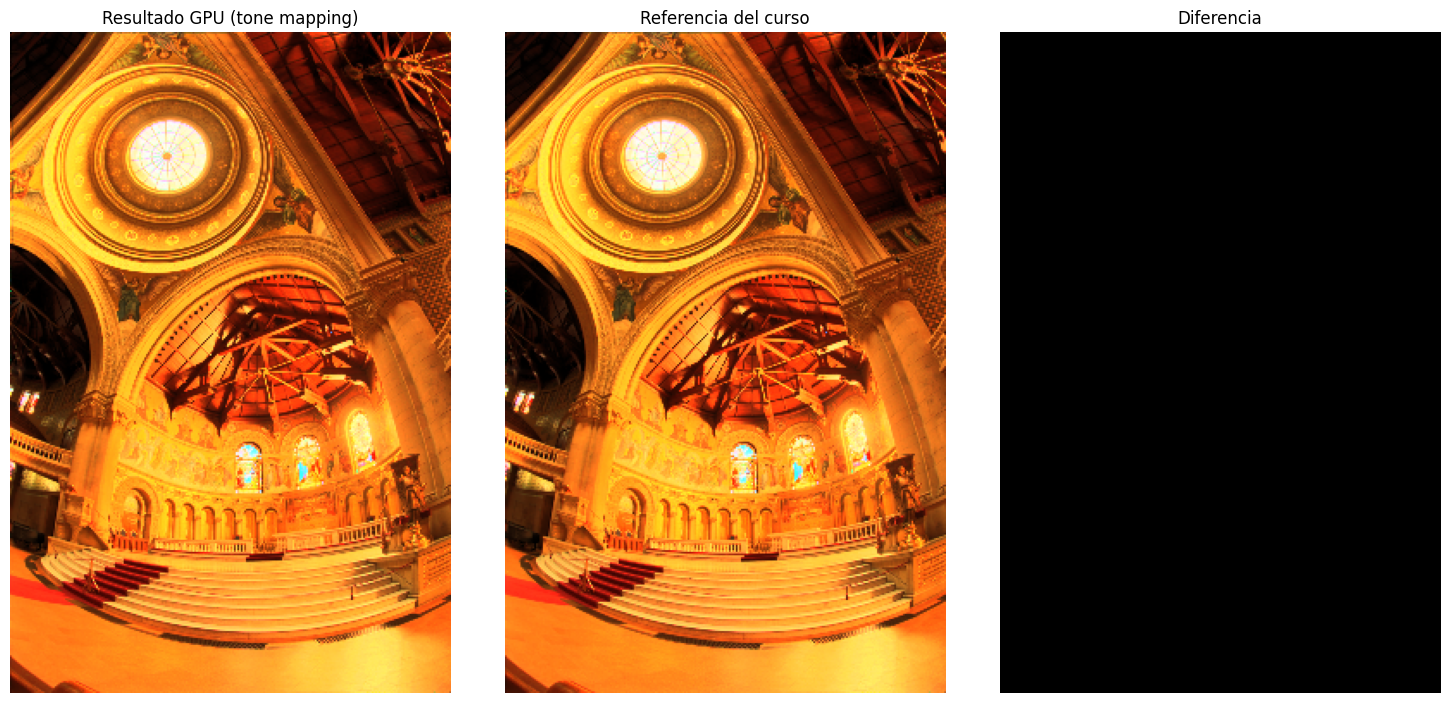

['memorial_raw.png', 'memorial_raw_large.png']


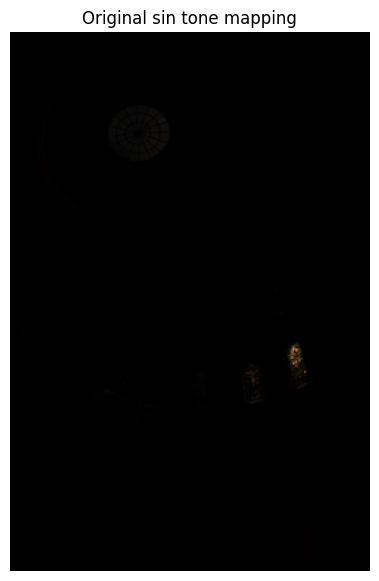

In [8]:
import cv2, numpy as np, matplotlib.pyplot as plt

imagenes = []
hdr = cv2.imread(entrada, cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH)
if hdr is not None:
    imagenes.append(('Original HDR (sin tone mapping)', np.clip(hdr[..., ::-1], 0, 1)))
for archivo, titulo in [('HW3_output.png', 'Resultado GPU (tone mapping)'),
                        ('HW3_reference.png', 'Referencia del curso'),
                        ('HW3_differenceImage.png', 'Diferencia')]:
    if os.path.exists(archivo):
        imagenes.append((titulo, cv2.imread(archivo)[..., ::-1]))

fig, ejes = plt.subplots(1, len(imagenes), figsize=(5 * len(imagenes), 7))
for ax, (titulo, img) in zip(np.atleast_1d(ejes), imagenes):
    ax.imshow(img); ax.set_title(titulo); ax.axis('off')
plt.tight_layout(); plt.show()


import glob
crudas = sorted(glob.glob('memorial_raw*.png'))
print(crudas)
if crudas:
    img = cv2.imread(crudas[0])[..., ::-1]
    plt.figure(figsize=(5, 7)); plt.imshow(img)
    plt.title('Original sin tone mapping'); plt.axis('off'); plt.show()